Best Neighborhood for Income to Rent Ration:
1             Point Breeze
2            Allegheny West
3            East Carnegie
4            Regent Square
5          Stanton Heights
6               Manchester
7                  Bon Air
8          Crafton Heights
9              Perry North
10                 Fineview
11    Spring Hill-City View
12               Mt. Oliver
13         Brighton Heights
14              Summer Hill
15            Lincoln Place

Best Neighborhood for Least amount of crime:
1 CHARTIERS CITY
2 MT. OLIVER NEIGHBORHOOD
3 MT. OLIVER BORO 
4 RIDGEMONT
5 ST. CLAIR
6 SUMMER HILL
7 NEW HOMESTEAD
8 ARLINGTON HEIGHTS
9 SWISSHELM PARK
10 REGENT SQUARE
11 SPRING GARDEN
12 OAKWOOD
13 HAYS
14 FAIRYWOOD

In [10]:
leastCrime = [
    'CHARTIERS CITY',
    'MT. OLIVER',
    'MT. OLIVER BORO',
    'RIDGEMONT',
    'ST. CLAIR',
    'SUMMER HILL',
    'NEW HOMESTEAD',
    'ARLINGTON HEIGHTS',
    'SWISSHELM PARK',
    'SPRING GARDEN',
    'REGENT SQUARE',
    'OAKWOOD',
    'HAYS',
    'FAIRYWOOD',
    'WINDGAP',
    'EAST CARNEGIE',
    'POLISH HILL',
    'BON AIR',
    'MORNINGSIDE',
    'DUQUESNE HEIGHTS',
    'UPPER HILL',
    'STANTON HEIGHTS',
    'MOUNT OLIVER',
    'WEST END',
    'FRIENDSHIP'
]

bestIncomeRatio = [
    "Point Breeze",
    "Allegheny West",
    "East Carnegie",
    "Regent Square",
    "Stanton Heights",  
    "Manchester",
    "Bon Air",
    "Crafton Heights",
    "Perry North",
    "Fineview",
    "Spring Hill-City View",
    "Mt. Oliver",
    "Brighton Heights",
    "Summer Hill",
    "Lincoln Place",
    "Squirrel Hill North",
    "Central Northside",
    "Highland Park",
    "Beechview",
    "Swisshelm Park",
    "Brookline",
    "Westwood",
    "Morningside",
    "Greenfield",
    "Polish Hill"
]

mostParks = [
    'BEECHVIEW',
    'SOUTH SIDE SLOPES',
    'HAZELWOOD',
    'MOUNT WASHINGTON',
    'TROY HILL',
    'SHERADEN',
    'EAST LIBERTY',
    'MARSHALL-SHADELAND',
    'ELLIOTT',
    'SOUTH OAKLAND',
    'BLOOMFIELD',
    'NORTH SHORE',
    'CRAWFORD-ROBERTS',
    'MANCHESTER',
    'CENTRAL BUSINESS DISTRICT',
    'UPPER LAWRENCEVILLE',
    'SQUIRREL HILL SOUTH',
    'CARRICK',
    'SPRING HILL-CITY VIEW',
    'GARFIELD',
    'SOUTH SIDE FLATS',
    'BRIGHTON HEIGHTS',
    'LOWER LAWRENCEVILLE',
    'BELTZHOOVER',
    'TERRACE VILLAGE'
]
both = []
incomeNPark = []
incomeNcrime = []
crimNpark = []
for i in range(len(bestIncomeRatio)):
    bestIncomeRatio[i] = bestIncomeRatio[i].lower()
for i in range(len(leastCrime)):
    leastCrime[i] = leastCrime[i].lower()
for i in range(len(mostParks)):
    mostParks[i] = mostParks[i].lower()
for neighborhood in leastCrime:
    if neighborhood in bestIncomeRatio and neighborhood in mostParks:
        both.append(neighborhood)
for neighborhood in leastCrime:
    if neighborhood in bestIncomeRatio:
        incomeNcrime.append(neighborhood)
for neighborhood in leastCrime:
    if neighborhood in mostParks:
        crimNpark.append(neighborhood)
for neighborhood in bestIncomeRatio:
    if neighborhood in mostParks:
        crimNpark.append(neighborhood)
print(both)
print(incomeNPark)
print(incomeNcrime)
print(crimNpark)

[]
[]
['mt. oliver', 'summer hill', 'swisshelm park', 'regent square', 'east carnegie', 'polish hill', 'bon air', 'morningside', 'stanton heights']
['manchester', 'spring hill-city view', 'brighton heights', 'beechview']


The list above shows different overlaps of neighborhoods in each of the criteria. 
The first one is overlap in all three, which we did not have.
The second one is income and parks, which we did not have an overlap as well.
The third is income and crime; for this, we had the most overlap. we can can narrow the list down if we look at the neighborhoods who are in one of the top 5 in either criterion. This gets us: mt. oliver, regent square, East Carnegie, stanton heights



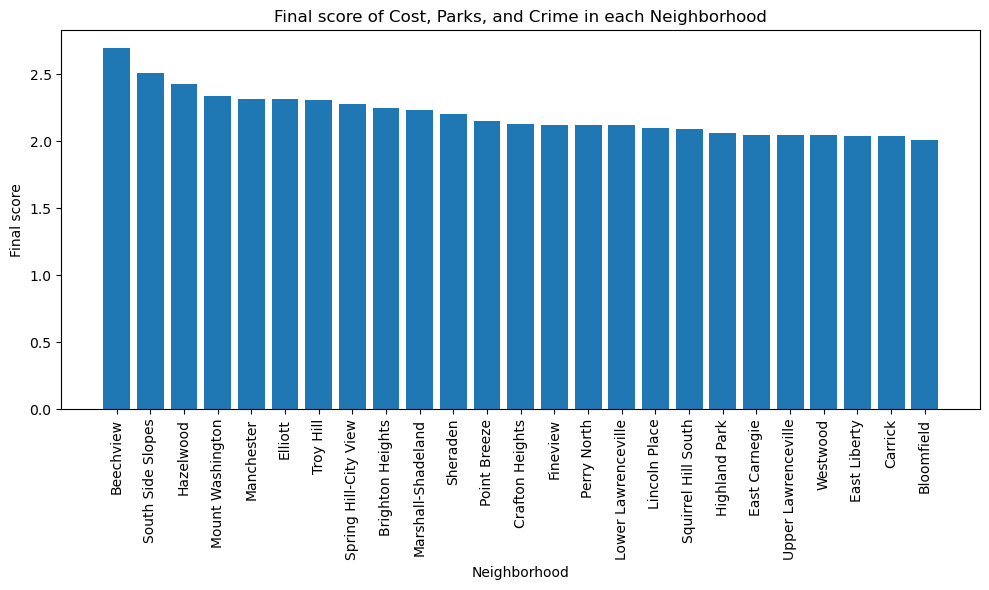

18                Beechview
50        South Side Slopes
32                Hazelwood
42         Mount Washington
5                Manchester
28                  Elliott
72                Troy Hill
10    Spring Hill-City View
12         Brighton Heights
41       Marshall-Shadeland
39                 Sheraden
0              Point Breeze
7           Crafton Heights
9                  Fineview
8               Perry North
38      Lower Lawrenceville
14            Lincoln Place
33      Squirrel Hill South
17            Highland Park
2             East Carnegie
52      Upper Lawrenceville
21                 Westwood
74             East Liberty
36                  Carrick
55               Bloomfield
Name: Neighborhood, dtype: object


In [55]:
import pandas as pd
import matplotlib.pyplot as plt

income = pd.read_csv("changedIncome.csv")
parks = pd.read_csv("changedParks.csv")
police = pd.read_csv("changedPolice.csv")

income = income.sort_values(by='rentIncomeRatio', ascending=False)
top = income["rentIncomeRatio"].iloc[0]

income["rentIncomeRatioPercent"] = 0.0
neighborhood = income["Neighborhood"].tolist()
for j in neighborhood:
    income.loc[income['Neighborhood'] == j, "rentIncomeRatioPercent"] = (income.loc[income['Neighborhood'] == j, "rentIncomeRatio"])/top
    

parks = parks.sort_values(by='count',ascending=False)
top = parks["count"].iloc[0]

parks["parkPercent"] = 1.0
neighborhood = parks["neighborhood"].tolist()
for j in neighborhood:
    parks.loc[parks['neighborhood'] == j, "parkPercent"] = (parks.loc[parks['neighborhood'] == j, "count"])/top


police = police.sort_values(by='Weighted_Score',ascending=False)
top = police["Weighted_Score"].iloc[0]
police = police.sort_values(by='Weighted_Score',ascending=True)

police["policePercent"] = 1.0
neighborhood = police["NEIGHBORHOOD"].tolist()
for j in neighborhood:
    police.loc[police['NEIGHBORHOOD'] == j, "policePercent"] = 1-((police.loc[police['NEIGHBORHOOD'] == j, "Weighted_Score"])/top)


income["finalScore"] = 0.0
neighborhood = income["Neighborhood"].tolist()
for j in neighborhood:
    # police
    s_police = police.loc[police['NEIGHBORHOOD'] == j.upper(), "policePercent"]
    police_val = s_police.iloc[0] if not s_police.empty else 0.0

    # parks
    s_parks = parks.loc[parks['neighborhood'] == j.upper(), "parkPercent"]
    parks_val = s_parks.iloc[0] if not s_parks.empty else 0.0

    # income
    s_income = income.loc[income['Neighborhood'] == j, "rentIncomeRatioPercent"]
    income_val = s_income.iloc[0] if not s_income.empty else 0.0

    income.loc[income['Neighborhood'] == j, "finalScore"] = (
        police_val + parks_val + income_val
    )

income = income.sort_values(by='finalScore', ascending=False)






income = income.sort_values(by='finalScore', ascending=False)
finalTop25 = income.head(25)

plt.figure(figsize=(10, 6))
plt.bar(finalTop25["Neighborhood"], finalTop25["finalScore"])
plt.xticks(rotation=90)
plt.xlabel("Neighborhood")
plt.ylabel("Final score")
plt.title("Final score of Cost, Parks, and Crime in each Neighborhood")
plt.tight_layout()
plt.show()
print(finalTop25["Neighborhood"])